In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import qpsolvers
from qpsolvers import solve_qp

# Download data
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'TSLA']
start_date = '2020-03-13'
end_date = '2024-05-16'

# Download price data
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Compute log returns
log_returns = np.log(data / data.shift(1)).dropna()

print(f"Data shape: {data.shape}")
print(f"Log returns shape: {log_returns.shape}")


/tmp/ipykernel_15193/4117523602.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed

Data shape: (1051, 5)
Log returns shape: (1050, 5)


Portfolio Matrix W:
[[ 2.00000000e-01 -7.01130844e-04  5.48915235e-04 -1.79879182e-06
   7.78254155e-04  9.99734944e-01  1.34353806e-05  2.96340860e-05
  -1.74669634e-05  5.39434545e-04 -1.16786246e-05  2.27796806e-04
   1.26370075e-05  1.28670178e-03 -1.27751170e-04  8.64959521e-06
   1.00785979e+00  1.79213328e-04 -4.57859476e-04 -6.35652024e-06
   2.07244712e-04  9.96207597e-01  1.20441893e-05  9.96967101e-01
   8.35763805e-04  1.59576734e-03  1.17151919e-03  4.74987843e-05
   1.00223826e+00  1.98023030e-03 -4.28031734e-04  9.16098993e-01
  -3.61308745e-04 -2.06451337e-04  1.83201308e-04 -1.44370154e-03
   9.92617432e-01  5.08337564e-04  2.05469160e-05 -9.68122016e-04
  -1.90249984e-07 -8.49465199e-05 -1.15777954e-05  1.00156870e+00
   1.81465982e-04 -3.52614161e-04 -3.42228707e-04 -1.63094884e-03
  -9.52979602e-05  7.85427809e-04]
 [ 2.00000000e-01  5.43796788e-01 -4.89321887e-05 -1.78867875e-06
   7.39243708e-04  4.03878360e-05 -1.27779361e-04  7.17969297e-06
  -5.47543339e-04  5.

ValueError: x and y must have same first dimension, but have shapes (1051,) and (1050,)

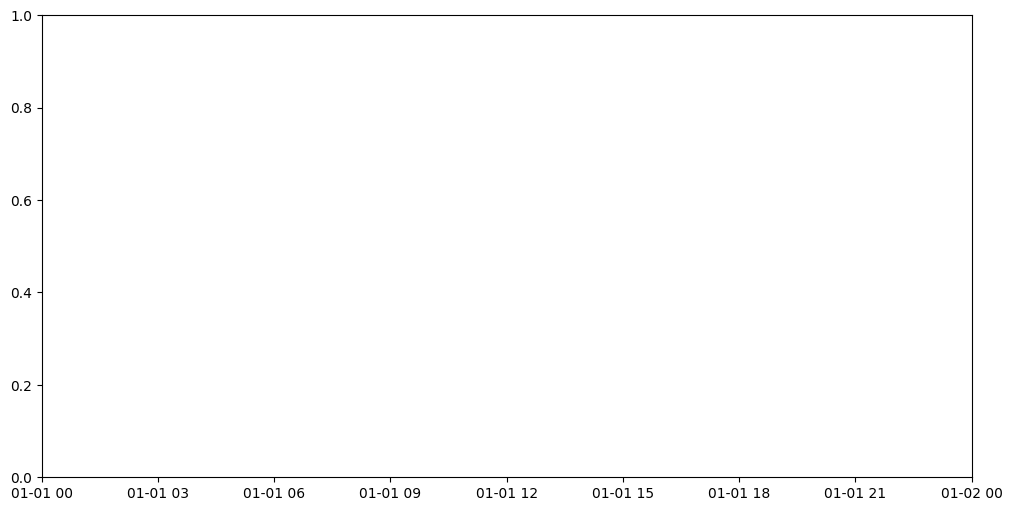

In [7]:
# Parameters
n_assets = 5
window_size = 21
lambda_param = 0.1
initial_capital = 1_000_000

# Initialize portfolio weights matrix
n_windows = len(log_returns) // window_size
W = np.zeros((n_assets, n_windows))

# Initialize with equal weights for first window
W[:, 0] = 1/n_assets

# Compute portfolio weights for each window
for i in range(1, n_windows):
    # Get returns for estimation window
    start_idx = (i-1) * window_size
    end_idx = i * window_size
    window_returns = log_returns.iloc[start_idx:end_idx].values
    
    # Compute sample mean and covariance
    mu = np.mean(window_returns, axis=0)
    Sigma = np.cov(window_returns.T)
    
    # Solve Markowitz optimization problem
    # min lambda * w^T Sigma w - w^T mu
    # s.t. 1^T w = 1, w >= 0
    
    P = 2 * lambda_param * Sigma
    q = -mu
    A = np.ones((1, n_assets))
    b = np.array([1.0])
    lb = np.zeros(n_assets)
    
    w = solve_qp(P, q, G=-np.eye(n_assets), h=-lb, A=A, b=b, solver='osqp')
    W[:, i] = w

# Print portfolio matrix
print("Portfolio Matrix W:")
print(W)

# Compute NAV
nav = np.zeros(len(log_returns) + 1)
nav[0] = initial_capital

# Track portfolio value
for t in range(len(log_returns)):
    window_idx = t // window_size
    if window_idx >= n_windows:
        window_idx = n_windows - 1
    
    weights = W[:, window_idx]
    daily_return = np.dot(weights, log_returns.iloc[t].values)
    nav[t+1] = nav[t] * np.exp(daily_return)

# Plot NAV
plt.figure(figsize=(12, 6))
dates = data.index
plt.plot(dates, nav[:-1], label='Portfolio NAV', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Net Asset Value ($)')
plt.title('Portfolio NAV Over Time')
plt.legend()
plt.grid(True)
plt.show()


Total transaction costs: $292,708.43


ValueError: x and y must have same first dimension, but have shapes (1051,) and (1050,)

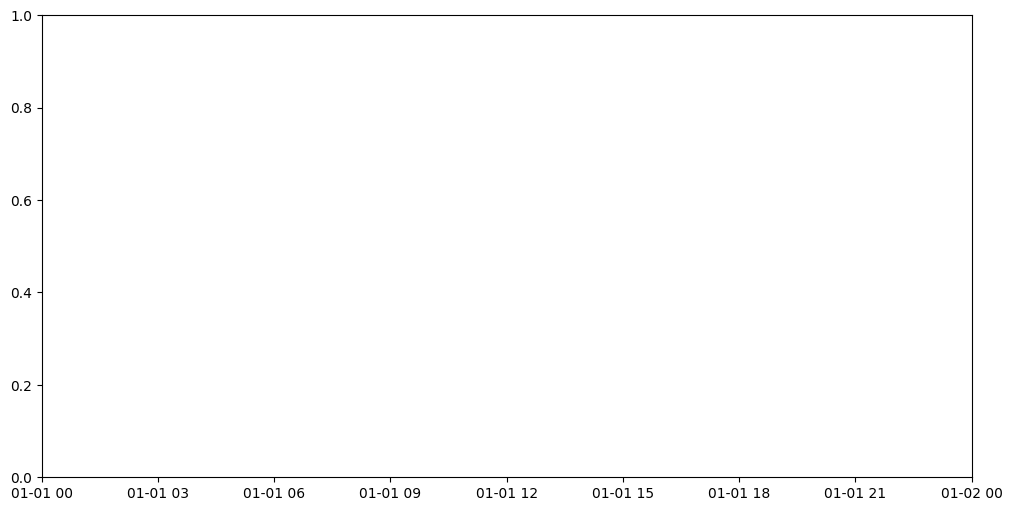

In [3]:
# Transaction cost rate (25 bps = 0.0025)
tc_rate = 0.0025

# Calculate transaction costs
total_tc = 0
tc_nav = np.zeros(len(log_returns) + 1)
tc_nav[0] = initial_capital

# Track previous weights
prev_weights = W[:, 0]

for t in range(len(log_returns)):
    window_idx = t // window_size
    if window_idx >= n_windows:
        window_idx = n_windows - 1
    
    current_weights = W[:, window_idx]
    
    # Calculate transaction costs only at rebalancing points
    if t % window_size == 0 and t > 0:
        # Calculate turnover
        turnover = np.sum(np.abs(current_weights - prev_weights))
        tc = tc_rate * tc_nav[t] * turnover
        total_tc += tc
        tc_nav[t] -= tc
        prev_weights = current_weights
    
    # Update NAV
    daily_return = np.dot(current_weights, log_returns.iloc[t].values)
    tc_nav[t+1] = tc_nav[t] * np.exp(daily_return)

print(f"Total transaction costs: ${total_tc:,.2f}")

# Overlay NAV plots
plt.figure(figsize=(12, 6))
plt.plot(dates, nav[:-1], label='NAV without TC', linewidth=2)
plt.plot(dates, tc_nav[:-1], label='NAV with TC', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Net Asset Value ($)')
plt.title('Portfolio NAV: With and Without Transaction Costs')
plt.legend()
plt.grid(True)
plt.show()
# Solve Markowitz with transaction cost penalty
gamma = 1.0
W_tc = np.zeros((n_assets, n_windows))
W_tc[:, 0] = 1/n_assets

for i in range(1, n_windows):
    start_idx = (i-1) * window_size
    end_idx = i * window_size
    window_returns = log_returns.iloc[start_idx:end_idx].values
    
    mu = np.mean(window_returns, axis=0)
    Sigma = np.cov(window_returns.T)
    
    # Previous weights
    w_prev = W_tc[:, i-1]
    
    # Solve: min lambda * w^T Sigma w - w^T mu + gamma * ||w - w_prev||_1
    # This requires reformulation with auxiliary variables
    # Let z = |w - w_prev|, then we have:
    # min lambda * w^T Sigma w - w^T mu + gamma * 1^T z
    # s.t. w - w_prev <= z, -(w - w_prev) <= z, 1^T w = 1, w >= 0, z >= 0
    
    # Variables: [w, z]
    n_vars = 2 * n_assets
    
    # Objective: quadratic part
    P = np.zeros((n_vars, n_vars))
    P[:n_assets, :n_assets] = 2 * lambda_param * Sigma
    
    # Objective: linear part
    q = np.zeros(n_vars)
    q[:n_assets] = -mu
    q[n_assets:] = gamma
    
    # Constraints
    # Equality: 1^T w = 1
    A_eq = np.zeros((1, n_vars))
    A_eq[0, :n_assets] = 1
    b_eq = np.array([1.0])
    
    # Inequality constraints
    # w - w_prev - z <= 0
    # -w + w_prev - z <= 0
    # -w <= 0
    # -z <= 0
    G = np.zeros((2*n_assets + 2*n_assets, n_vars))
    h = np.zeros(2*n_assets + 2*n_assets)
    
    # w - w_prev - z <= 0
    G[:n_assets, :n_assets] = np.eye(n_assets)
    G[:n_assets, n_assets:] = -np.eye(n_assets)
    h[:n_assets] = w_prev
    
    # -w + w_prev - z <= 0
    G[n_assets:2*n_assets, :n_assets] = -np.eye(n_assets)
    G[n_assets:2*n_assets, n_assets:] = -np.eye(n_assets)
    h[n_assets:2*n_assets] = -w_prev
    
    # -w <= 0 (w >= 0)
    G[2*n_assets:3*n_assets, :n_assets] = -np.eye(n_assets)
    
    # -z <= 0 (z >= 0)
    G[3*n_assets:, n_assets:] = -np.eye(n_assets)
    
    solution = solve_qp(P, q, G, h, A_eq, b_eq, solver='osqp')
    W_tc[:, i] = solution[:n_assets]

print("Portfolio Matrix W with TC penalty:")
print(W_tc)

# Calculate actual transaction costs
total_tc_new = 0
tc_nav_new = np.zeros(len(log_returns) + 1)
tc_nav_new[0] = initial_capital
prev_weights = W_tc[:, 0]

for t in range(len(log_returns)):
    window_idx = t // window_size
    if window_idx >= n_windows:
        window_idx = n_windows - 1
    
    current_weights = W_tc[:, window_idx]
    
    if t % window_size == 0 and t > 0:
        turnover = np.sum(np.abs(current_weights - prev_weights))
        tc = tc_rate * tc_nav_new[t] * turnover
        total_tc_new += tc
        tc_nav_new[t] -= tc
        prev_weights = current_weights
    
    daily_return = np.dot(current_weights, log_returns.iloc[t].values)
    tc_nav_new[t+1] = tc_nav_new[t] * np.exp(daily_return)

print(f"Total TC (original): ${total_tc:,.2f}")
print(f"Total TC (with penalty): ${total_tc_new:,.2f}")

# Plot all NAVs
plt.figure(figsize=(12, 6))
plt.plot(dates, nav[:-1], label='NAV without TC', linewidth=2, alpha=0.7)
plt.plot(dates, tc_nav[:-1], label='NAV with TC (original)', linewidth=2)
plt.plot(dates, tc_nav_new[:-1], label='NAV with TC (optimized)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Net Asset Value ($)')
plt.title('Portfolio NAV Comparison')
plt.legend()
plt.grid(True)
plt.show()


Portfolio Matrix W with TC penalty:
[[0.2        0.19993583 0.19993772 0.199933   0.19992133 0.19993478
  0.1999292  0.1999261  0.19991963 0.19990746 0.19989914 0.1998957
  0.19989109 0.19988965 0.19988323 0.19987971 0.19988702 0.19988113
  0.19987984 0.1998774  0.19987259 0.19989469 0.19988981 0.19989484
  0.19989216 0.19988656 0.19988244 0.19988025 0.19988664 0.19988277
  0.19987882 0.19987905 0.1998692  0.19986657 0.19985502 0.19984186
  0.1998459  0.19984647 0.19984381 0.19983591 0.19983364 0.19982717
  0.19982568 0.19983156 0.19982527 0.1998242  0.19982197 0.19981431
  0.19980921 0.19980638]
 [0.2        0.19996216 0.19995716 0.19995459 0.19994093 0.19993739
  0.19993373 0.19993002 0.19992795 0.1999184  0.19991316 0.19990882
  0.19990277 0.19990434 0.19989793 0.19989825 0.19989637 0.19989819
  0.19990096 0.19989896 0.1998925  0.19988603 0.19988274 0.19988122
  0.1998816  0.19987473 0.19987126 0.19987173 0.1998672  0.19987445
  0.19987081 0.19986873 0.19986356 0.19985937 0.1998692 

ValueError: x and y must have same first dimension, but have shapes (1051,) and (1050,)

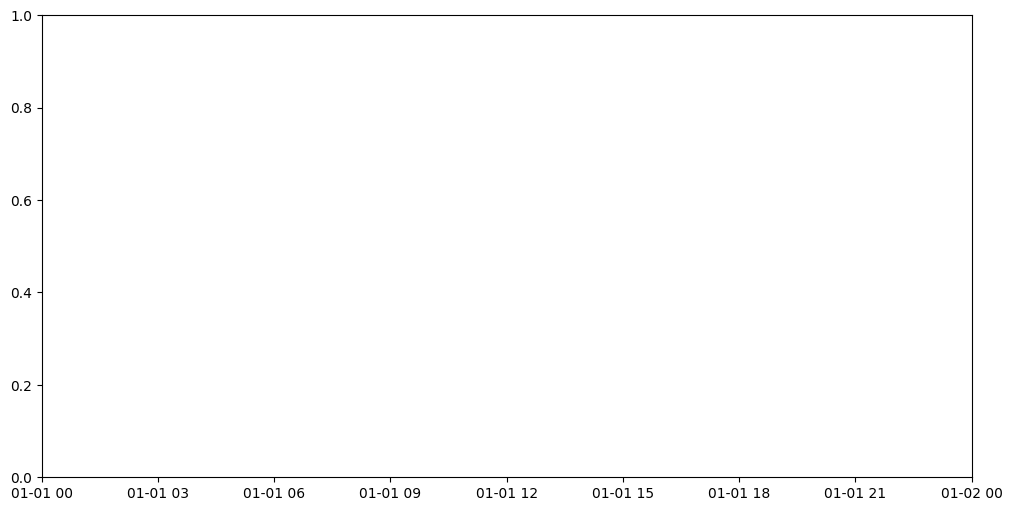

In [4]:
# Solve Markowitz with transaction cost penalty
gamma = 1.0
W_tc = np.zeros((n_assets, n_windows))
W_tc[:, 0] = 1/n_assets

for i in range(1, n_windows):
    start_idx = (i-1) * window_size
    end_idx = i * window_size
    window_returns = log_returns.iloc[start_idx:end_idx].values
    
    mu = np.mean(window_returns, axis=0)
    Sigma = np.cov(window_returns.T)
    
    # Previous weights
    w_prev = W_tc[:, i-1]
    
    # Solve: min lambda * w^T Sigma w - w^T mu + gamma * ||w - w_prev||_1
    # This requires reformulation with auxiliary variables
    # Let z = |w - w_prev|, then we have:
    # min lambda * w^T Sigma w - w^T mu + gamma * 1^T z
    # s.t. w - w_prev <= z, -(w - w_prev) <= z, 1^T w = 1, w >= 0, z >= 0
    
    # Variables: [w, z]
    n_vars = 2 * n_assets
    
    # Objective: quadratic part
    P = np.zeros((n_vars, n_vars))
    P[:n_assets, :n_assets] = 2 * lambda_param * Sigma
    
    # Objective: linear part
    q = np.zeros(n_vars)
    q[:n_assets] = -mu
    q[n_assets:] = gamma
    
    # Constraints
    # Equality: 1^T w = 1
    A_eq = np.zeros((1, n_vars))
    A_eq[0, :n_assets] = 1
    b_eq = np.array([1.0])
    
    # Inequality constraints
    # w - w_prev - z <= 0
    # -w + w_prev - z <= 0
    # -w <= 0
    # -z <= 0
    G = np.zeros((2*n_assets + 2*n_assets, n_vars))
    h = np.zeros(2*n_assets + 2*n_assets)
    
    # w - w_prev - z <= 0
    G[:n_assets, :n_assets] = np.eye(n_assets)
    G[:n_assets, n_assets:] = -np.eye(n_assets)
    h[:n_assets] = w_prev
    
    # -w + w_prev - z <= 0
    G[n_assets:2*n_assets, :n_assets] = -np.eye(n_assets)
    G[n_assets:2*n_assets, n_assets:] = -np.eye(n_assets)
    h[n_assets:2*n_assets] = -w_prev
    
    # -w <= 0 (w >= 0)
    G[2*n_assets:3*n_assets, :n_assets] = -np.eye(n_assets)
    
    # -z <= 0 (z >= 0)
    G[3*n_assets:, n_assets:] = -np.eye(n_assets)
    
    solution = solve_qp(P, q, G, h, A_eq, b_eq, solver='osqp')
    W_tc[:, i] = solution[:n_assets]

print("Portfolio Matrix W with TC penalty:")
print(W_tc)

# Calculate actual transaction costs
total_tc_new = 0
tc_nav_new = np.zeros(len(log_returns) + 1)
tc_nav_new[0] = initial_capital
prev_weights = W_tc[:, 0]

for t in range(len(log_returns)):
    window_idx = t // window_size
    if window_idx >= n_windows:
        window_idx = n_windows - 1
    
    current_weights = W_tc[:, window_idx]
    
    if t % window_size == 0 and t > 0:
        turnover = np.sum(np.abs(current_weights - prev_weights))
        tc = tc_rate * tc_nav_new[t] * turnover
        total_tc_new += tc
        tc_nav_new[t] -= tc
        prev_weights = current_weights
    
    daily_return = np.dot(current_weights, log_returns.iloc[t].values)
    tc_nav_new[t+1] = tc_nav_new[t] * np.exp(daily_return)

print(f"Total TC (original): ${total_tc:,.2f}")
print(f"Total TC (with penalty): ${total_tc_new:,.2f}")

# Plot all NAVs
plt.figure(figsize=(12, 6))
plt.plot(dates, nav[:-1], label='NAV without TC', linewidth=2, alpha=0.7)
plt.plot(dates, tc_nav[:-1], label='NAV with TC (original)', linewidth=2)
plt.plot(dates, tc_nav_new[:-1], label='NAV with TC (optimized)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Net Asset Value ($)')
plt.title('Portfolio NAV Comparison')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
def calculate_performance_metrics(nav, risk_free_rate=0.02):
    # Daily returns
    returns = np.diff(nav) / nav[:-1]
    
    # Annualized return
    total_return = (nav[-1] / nav[0]) - 1
    n_years = len(returns) / 252  # Assuming 252 trading days per year
    annualized_return = (1 + total_return) ** (1/n_years) - 1
    
    # Annualized volatility
    daily_vol = np.std(returns)
    annualized_vol = daily_vol * np.sqrt(252)
    
    # Sharpe ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
    
    # Maximum drawdown
    cumulative = nav / nav[0]
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown)
    
    return {
        'Annualized Return': annualized_return,
        'Annualized Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

# Calculate metrics for both portfolios
metrics_original = calculate_performance_metrics(tc_nav[:-1])
metrics_optimized = calculate_performance_metrics(tc_nav_new[:-1])

print("\nPerformance Metrics (Original Portfolio with TC):")
for metric, value in metrics_original.items():
    print(f"{metric}: {value:.4f}")

print("\nPerformance Metrics (Optimized Portfolio with TC):")
for metric, value in metrics_optimized.items():
    print(f"{metric}: {value:.4f}")



Performance Metrics (Original Portfolio with TC):
Annualized Return: -0.0140
Annualized Sharpe Ratio: -0.0802
Maximum Drawdown: -0.7118

Performance Metrics (Optimized Portfolio with TC):
Annualized Return: 0.2795
Annualized Sharpe Ratio: 0.8898
Maximum Drawdown: -0.4417
